# Strategy Asset Ensembles vs Common Benchmark

## Objective
Build one **cross-asset portfolio per strategy architecture** and compare each to a **common benchmark**.

This notebook is intentionally **strategy-focused** (portfolio construction + risk/return diagnostics), not statistical-significance testing.

## Methodology
- Assets: `QQQ`, `NKY`, `EUSTX`
- Strategies: `LSTM-1`, `LSTM-2`, `NC-1`, `NC-2`, `Transformer`
- For each strategy, construct one cross-asset portfolios:
  1. **Equal-weight (EW)** across the three assets
- Common benchmark: equal-weight average of each market's `QQQ Buy-and-Hold` return series

## Reported Metrics
`AR (%)`, `ARC (%)`, `ASD (%)`, `MD (%)`, `MLD`, `IR1`, `IR2`, `Sharpe`

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120

ANNUALIZATION = 252
ROLLING_VOL_WINDOW = 63
EPSILON = 1e-12

RESULTS_DIR = Path("../../Results_Daily")
OUTPUT_DIR = RESULTS_DIR / "Ensemble"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MARKETS = ["QQQ", "NKY", "EUSTX"]
STRATEGIES = {
    "LSTM-1": "LSTM_DAILY_1",
    "LSTM-2": "LSTM_DAILY_2",
    "NC-1": "LSTM_NC_DAILY",
    "NC-2": "LSTM_NC_DAILY_2",
    "Transformer": "TRANSFORMERS_DAILY_1",
}
BENCHMARK_COLUMN = "QQQ Buy-and-Hold"

print(f"Results directory: {RESULTS_DIR.resolve()}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Results directory: /Users/kamilkashif/Documents/University/Masters Thesis/MS-Thesis-Deep-RL-KK/Results_Daily
Output directory: /Users/kamilkashif/Documents/University/Masters Thesis/MS-Thesis-Deep-RL-KK/Results_Daily/Ensemble


In [11]:
def load_rl_returns(market: str, run_name: str) -> pd.Series:
    path = RESULTS_DIR / market / run_name / "rl_daily_returns_oos.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing RL file: {path}")

    df = pd.read_csv(path)
    if "date" not in df.columns:
        df = df.rename(columns={df.columns[0]: "date"})

    if "RL Agent" in df.columns:
        return_col = "RL Agent"
    elif "portfolio_return_net" in df.columns:
        return_col = "portfolio_return_net"
    else:
        candidates = [c for c in df.columns if c != "date"]
        if not candidates:
            raise ValueError(f"No return column found in {path}")
        return_col = candidates[0]

    out = df[["date", return_col]].copy()
    out["date"] = pd.to_datetime(out["date"])
    return out.set_index("date")[return_col].sort_index()


def load_benchmark_returns(market: str) -> pd.Series:
    reference_run = f"{market}_LSTM_DAILY_1"
    path = RESULTS_DIR / market / reference_run / "daily_returns_oos.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing benchmark file: {path}")

    df = pd.read_csv(path)
    if BENCHMARK_COLUMN not in df.columns:
        raise ValueError(f"Column '{BENCHMARK_COLUMN}' not found in {path}")

    out = df[["date", BENCHMARK_COLUMN]].copy()
    out["date"] = pd.to_datetime(out["date"])
    return out.set_index("date")[BENCHMARK_COLUMN].sort_index()


def compute_metrics(returns: pd.Series, ann: int = ANNUALIZATION) -> dict:
    returns = returns.dropna()
    equity = (1.0 + returns).cumprod()

    total_return = equity.iloc[-1] - 1.0
    n_years = len(returns) / ann
    arc = (1.0 + total_return) ** (1.0 / n_years) - 1.0 if n_years > 0 else np.nan

    asd = returns.std() * np.sqrt(ann)
    mean_ann = returns.mean() * ann
    sharpe = mean_ann / asd if asd > 0 else np.nan

    peak = equity.cummax()
    drawdown = equity / peak - 1.0
    md = abs(drawdown.min())

    underwater = drawdown < 0
    if underwater.any():
        groups = (~underwater).cumsum()
        lengths = underwater.groupby(groups).sum()
        mld = lengths.max() / ann if len(lengths) > 0 else 0.0
    else:
        mld = 0.0

    ir1_raw = arc / asd if asd > 0 else np.nan
    calmar = arc / md if md > 0 else np.nan
    ir2_raw = ir1_raw * calmar if pd.notna(ir1_raw) and pd.notna(calmar) else np.nan

    # Keep IR3 definition consistent with the new equity notebooks:
    # IR3 = ARC^3 / (ASD * MD * MLD)
    denom_ir3 = asd * md * mld
    ir3 = (arc ** 3) / denom_ir3 if denom_ir3 > 0 else np.nan

    return {
        "N Days": len(returns),
        "AR (%)": total_return * 100.0,
        "ARC (%)": arc * 100.0,
        "ASD (%)": asd * 100.0,
        "MD (%)": md * 100.0,
        "MLD": mld,
        "IR1": ir1_raw * 100.0 if pd.notna(ir1_raw) else np.nan,
        "IR2": ir2_raw * 100.0 if pd.notna(ir2_raw) else np.nan,
        "IR3": ir3 * 100.0 if pd.notna(ir3) else np.nan,
        "Sharpe": sharpe,
    }


def build_risk_balanced_portfolio(df_returns: pd.DataFrame, window: int = ROLLING_VOL_WINDOW) -> tuple[pd.Series, pd.DataFrame]:
    rolling_vol = df_returns.rolling(window).std()
    inv_vol = 1.0 / (rolling_vol + EPSILON)
    weights = inv_vol.div(inv_vol.sum(axis=1), axis=0)

    # Lag by one day to avoid look-ahead bias.
    weights = weights.shift(1)

    # Fallback to equal-weight for early rows with missing rolling estimates.
    fallback = pd.DataFrame(
        np.full(df_returns.shape, 1.0 / df_returns.shape[1]),
        index=df_returns.index,
        columns=df_returns.columns,
    )
    weights = weights.where(weights.notna(), fallback)

    portfolio = (weights * df_returns).sum(axis=1)
    return portfolio, weights

In [12]:
# Load per-strategy, per-market return series
strategy_market_data = {}
coverage_rows = []

for strategy_label, strategy_suffix in STRATEGIES.items():
    market_series = []
    for market in MARKETS:
        run_name = f"{market}_{strategy_suffix}"
        series = load_rl_returns(market, run_name).rename(market)
        market_series.append(series)

    df_strategy = pd.concat(market_series, axis=1).dropna()
    strategy_market_data[strategy_label] = df_strategy

    coverage_rows.append(
        {
            "Strategy": strategy_label,
            "N Days": len(df_strategy),
            "Start": df_strategy.index.min().date(),
            "End": df_strategy.index.max().date(),
        }
    )

coverage_df = pd.DataFrame(coverage_rows).sort_values("Strategy").reset_index(drop=True)
print("Coverage of cross-asset strategy panels:")
display(coverage_df)

# Load and build common benchmark
benchmark_per_market = [load_benchmark_returns(m).rename(m) for m in MARKETS]
benchmark_df = pd.concat(benchmark_per_market, axis=1).dropna()
common_benchmark = benchmark_df.mean(axis=1)
common_benchmark.name = "Common Benchmark"

print(f"Common benchmark: {len(common_benchmark)} days, {common_benchmark.index.min().date()} -> {common_benchmark.index.max().date()}")

Coverage of cross-asset strategy panels:


/var/folders/zd/yhfq_ps96033lyz86hzc79cm0000gn/T/ipykernel_54606/701591261.py:12: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_strategy = pd.concat(market_series, axis=1).dropna()
/var/folders/zd/yhfq_ps96033lyz86hzc79cm0000gn/T/ipykernel_54606/701591261.py:12: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_strategy = pd.concat(market_series, axis=1).dropna()
/var/folders/zd/yhfq_ps96033lyz86hzc79cm0000gn/T/ipykernel_54606/701591261.py:12: Pandas4Warning: Sorting by default when concat

,Strategy,N Days,Start,End
0,LSTM-1,3736,2009-04-03,2025-03-28
1,LSTM-2,3736,2009-04-03,2025-03-28
2,NC-1,3736,2009-04-03,2025-03-28
3,NC-2,3736,2009-04-03,2025-03-28
4,Transformer,3736,2009-04-03,2025-03-28


Common benchmark: 3760 days, 2009-04-06 -> 2025-03-28


/var/folders/zd/yhfq_ps96033lyz86hzc79cm0000gn/T/ipykernel_54606/701591261.py:30: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  benchmark_df = pd.concat(benchmark_per_market, axis=1).dropna()


In [13]:
# Construct strategy portfolios
portfolio_returns = {"Common Benchmark": common_benchmark}
risk_balanced_weights = {}

for strategy_label, df_strategy in strategy_market_data.items():
    ew = df_strategy.mean(axis=1)
    ew.name = f"{strategy_label} (EW)"


    portfolio_returns[ew.name] = ew

portfolio_panel = pd.concat(portfolio_returns.values(), axis=1).dropna()
print(f"Aligned portfolio panel: {portfolio_panel.shape[0]} days x {portfolio_panel.shape[1]} series")
print(f"Date range: {portfolio_panel.index.min().date()} -> {portfolio_panel.index.max().date()}")
display(portfolio_panel.head())

Aligned portfolio panel: 3735 days x 6 series
Date range: 2009-04-06 -> 2025-03-28


/var/folders/zd/yhfq_ps96033lyz86hzc79cm0000gn/T/ipykernel_54606/2916691047.py:12: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  portfolio_panel = pd.concat(portfolio_returns.values(), axis=1).dropna()


,Common Benchmark,LSTM-1 (EW),LSTM-2 (EW),NC-1 (EW),NC-2 (EW),Transformer (EW)
date,,,,,,
2009-04-06,-0.007383,-0.005771,-0.002766,-0.001653,-0.004492,-0.005397
2009-04-07,-0.017967,-0.012307,-0.009431,-0.013629,-0.012879,-0.012141
2009-04-08,0.002600,0.008243,-0.001203,0.002688,0.002065,0.006366
2009-04-09,0.033072,0.026647,0.028292,0.035436,0.035668,0.027588
2009-04-14,-0.006199,0.001107,-0.000144,-0.001050,0.000308,0.001554


In [14]:
# Performance summary with requested metric set
summary_rows = []

for col in portfolio_panel.columns:
    m = compute_metrics(portfolio_panel[col])
    m.update({"Series": col})
    summary_rows.append(m)

summary_df = pd.DataFrame(summary_rows)[
    [
        "Series",
        "AR (%)",
        "ARC (%)",
        "ASD (%)",
        "MD (%)",
        "MLD",
        "IR1",
        "IR2",
        "IR3",
        "Sharpe",
    ]
].sort_values("Series").reset_index(drop=True)

print("Performance summary (requested metrics, no ADT)")
display(
    summary_df.style.format(
        {
            "AR (%)": "{:.2f}",
            "ARC (%)": "{:.2f}",
            "ASD (%)": "{:.2f}",
            "MD (%)": "{:.2f}",
            "MLD": "{:.2f}",
            "IR1": "{:.4f}",
            "IR2": "{:.4f}",
            "IR3": "{:.4f}",
            "Sharpe": "{:.4f}",
        }
    )
)

Performance summary (requested metrics, no ADT)


,Series,AR (%),ARC (%),ASD (%),MD (%),MLD,IR1,IR2,IR3,Sharpe
0,Common Benchmark,486.79,12.68,16.53,28.63,1.70,76.7260,33.9885,2.5317,0.8055
1,LSTM-1 (EW),514.60,13.03,14.72,28.16,1.79,88.5148,40.9624,2.9830,0.9062
2,LSTM-2 (EW),390.49,11.33,12.75,25.46,1.75,88.8022,39.4991,2.5506,0.9054
3,NC-1 (EW),487.84,12.69,16.14,28.76,1.98,78.6713,34.7214,2.2304,0.8218
4,NC-2 (EW),483.44,12.64,15.76,28.77,1.79,80.1607,35.2136,2.4865,0.8342
5,Transformer (EW),451.32,12.21,14.77,27.92,1.77,82.6431,36.1400,2.4872,0.8541


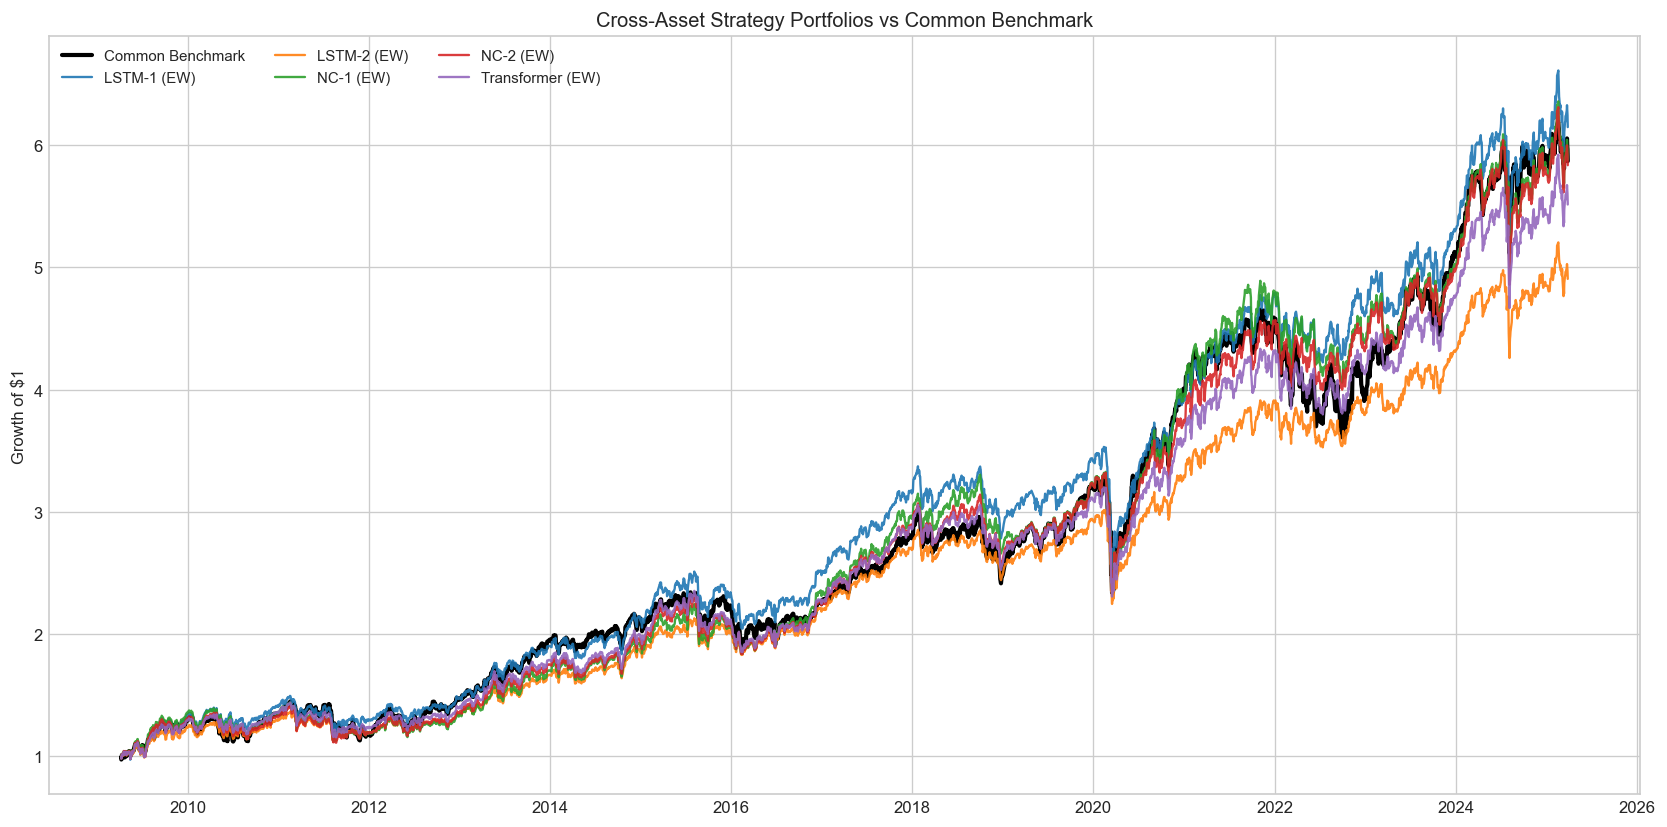

In [7]:
# Plot equity curves (all portfolios)
equity_panel = (1.0 + portfolio_panel).cumprod()

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(equity_panel.index, equity_panel["Common Benchmark"], linewidth=2.5, color="black", label="Common Benchmark")

for strategy_label in STRATEGIES.keys():
    ax.plot(equity_panel.index, equity_panel[f"{strategy_label} (EW)"], linewidth=1.4, alpha=0.9, label=f"{strategy_label} (EW)")

ax.set_title("Cross-Asset Strategy Portfolios vs Common Benchmark")
ax.set_ylabel("Growth of $1")
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()

# plot_path = OUTPUT_DIR / "strategy_asset_ensembles_equity_all.png"
# plt.savefig(plot_path, bbox_inches="tight")
plt.show()
# print(f"Saved plot: {plot_path}")

In [8]:
summary_df['Series'] = ["Buy&Hold", "LSTM_1", "LSTM_2", "LSTM_NC_DAILY", "LSTM_NC_DAILY_2", "TRANSFORMERS"]
portfolio_panel.columns = ["Benchmark", "LSTM_1 (EW)", "LSTM_2 (EW)", "LSTM_NC_DAILY (EW)", "LSTM_NC_DAILY_2 (EW)", "TRANSFORMERS (EW)"]
equity_panel.columns = ["Benchmark", "LSTM_1 (EW)", "LSTM_2 (EW)", "LSTM_NC_DAILY (EW)", "LSTM_NC_DAILY_2 (EW)", "TRANSFORMERS (EW)"]

In [9]:
# Save outputs
portfolio_panel.to_csv(OUTPUT_DIR / "portfolio_returns_panel.csv")
equity_panel.to_csv(OUTPUT_DIR / "equity_curves_oos.csv")
summary_df.to_csv(OUTPUT_DIR / "performance_metrics_oos.csv", index=False)

print(f"Saved CSV outputs to: {OUTPUT_DIR}")

Saved CSV outputs to: ../../Results_Daily/Ensemble
